In [ ]:
# ======================================
# IMPORT LIBRARY
# ======================================

# Library untuk manipulasi data
import pandas as pd
import numpy as np

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Setting tampilan visual yang lebih bagus
sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)  # tampilkan angka dengan 2 desimal

## **1. Dataset Audit**
Tujuan: Memahami isi data secara mendalam sebelum melakukan preprocessing  
- Ukuran dataset  
- Tipe data & missing value  
- Statistik deskriptif  
- Distribusi variabel kategorikal  
- Distribusi target (Price) & deteksi outlier

In [ ]:
# Load dataset
df = pd.read_csv("/content/sample_data/House Price Prediction Dataset.csv")
# 5 baris pertama untuk melihat struktur data
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
# Cek ukuran dataset (baris, kolom)
print("Ukuran dataset:", df.shape)
print("\nKolom:", df.columns.tolist())

# Cek tipe data setiap kolom dan jumlah non-null
print("\nInfo dataset:")
df.info()

# Cek Missing Value
print("\nMissing values:")
print(df.isnull().sum())

# Cek duplikat baris
print("\nDuplikat baris:", df.duplicated().sum())

Ukuran dataset: (2000, 10)

Kolom: ['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB

Missing values:
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

Duplikat baris: 0


In [ ]:
# Ringkasan statistik
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,1000.50,2786.21,3.00,2.55,1.99,1961.45,537676.85
std,577.49,1295.15,1.42,1.11,0.81,35.93,276428.85
min,1.00,501.00,1.00,1.00,1.00,1900.00,50005.00
25%,500.75,1653.00,2.00,2.00,1.00,1930.00,300098.00
50%,1000.50,2833.00,3.00,3.00,2.00,1961.00,539254.00
75%,1500.25,3887.50,4.00,4.00,3.00,1993.00,780086.00
max,2000.00,4999.00,5.00,4.00,3.00,2023.00,999656.00


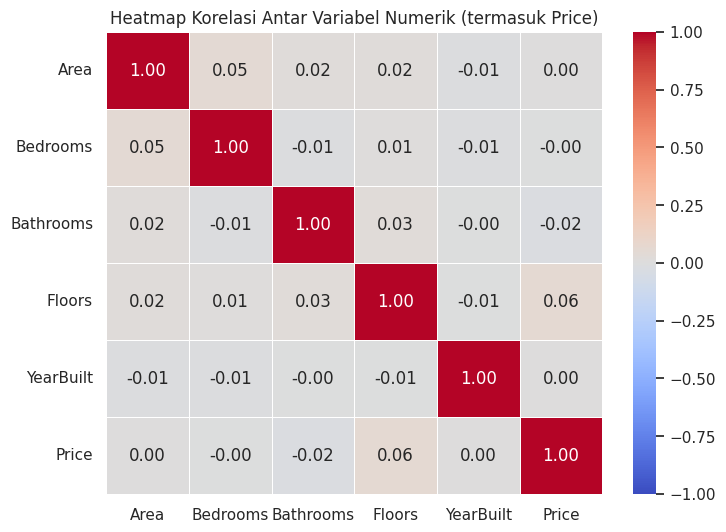

In [ ]:
# ======================================
# Heatmap Korelasi (hanya kolom numerik)
# ======================================

# Pilih kolom numerik termasuk target
numerical_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']
corr_matrix = df[numerical_cols].corr()

# Buat heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,               # tampilkan angka korelasi
    fmt=".2f",                # 2 desimal
    cmap="coolwarm",          # warna merah (positif) - biru (negatif)
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Heatmap Korelasi Antar Variabel Numerik (termasuk Price)")
plt.show()

**Insight dari Heatmap Korelasi:**
- Korelasi seluruh fitur numerik terhadap Price sangat rendah.
Nilai tertinggi diperoleh oleh Floors (0.06), diikuti Bathrooms (-0.02).
Area, Bedrooms, dan YearBuilt menunjukkan korelasi mendekati 0 terhadap Price.
Hubungan linear antar fitur numerik pada dataset ini tidak signifikan.

In [ ]:
# Distribusi Variabel Kategorikal
print("Location:")
print(df['Location'].value_counts(normalize=True).round(3)*100)

print("\nCondition:")
print(df['Condition'].value_counts(normalize=True).round(3)*100)

print("\nGarage:")
print(df['Garage'].value_counts(normalize=True).round(3)*100)

Location:
Location
Downtown   27.90
Urban      24.20
Suburban   24.20
Rural      23.70
Name: proportion, dtype: float64

Condition:
Condition
Fair        26.00
Excellent   25.60
Poor        25.40
Good        23.00
Name: proportion, dtype: float64

Garage:
Garage
No    51.90
Yes   48.10
Name: proportion, dtype: float64


Statistik Price:
count     2000.00
mean    537676.85
std     276428.85
min      50005.00
25%     300098.00
50%     539254.00
75%     780086.00
max     999656.00
Name: Price, dtype: float64
Skewness: -0.06
Kurtosis: -1.20


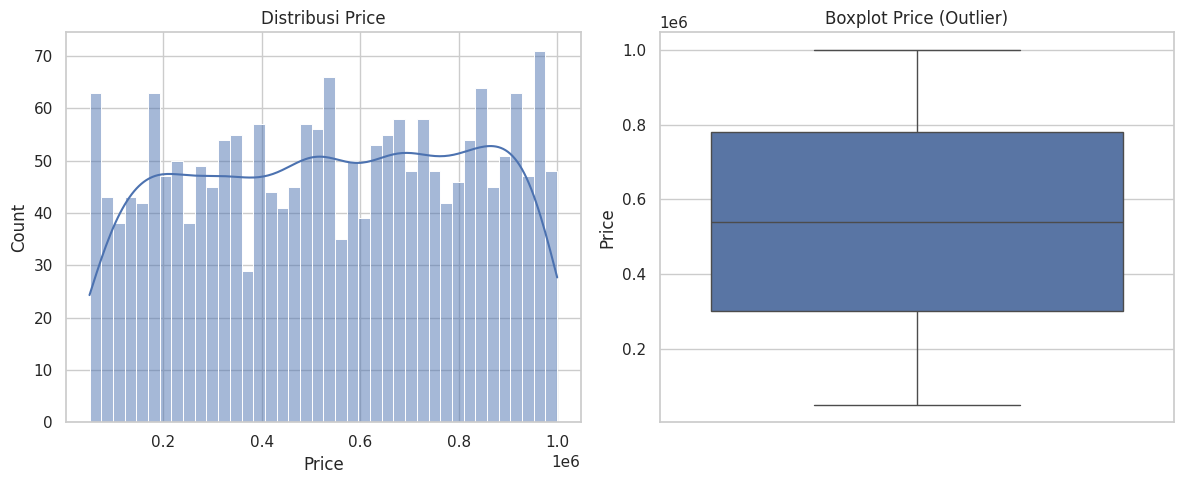

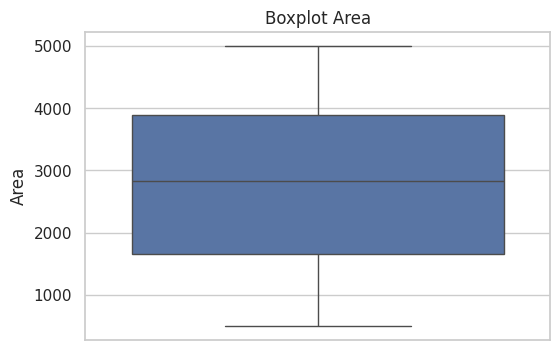

In [ ]:
# Distribusi Target (Price) & Deteksi Outlier
print("Statistik Price:")
print(df['Price'].describe())
print(f"Skewness: {df['Price'].skew():.2f}")
print(f"Kurtosis: {df['Price'].kurtosis():.2f}")

# Visual
plt.figure(figsize=(12, 5))

# Histogram + KDE
plt.subplot(1, 2, 1)
sns.histplot(df['Price'], kde=True, bins=40)
plt.title('Distribusi Price')

# Boxplot untuk melihat outlier
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Price'])
plt.title('Boxplot Price (Outlier)')

plt.tight_layout()
plt.show()

# Boxplot tambahan untuk Area (fitur penting)
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Area'])
plt.title('Boxplot Area')
plt.show()

**Insight dari Dataset Audit:**

- Dataset terdiri dari 2000 baris dan 10 kolom, tanpa missing value dan duplikat.

Distribusi variabel kategorikal terbilang seimbang:
- Location: Downtown (27.9%), Urban & Suburban (24.2%), Rural (23.7%)
- Condition: Fair (26%), Excellent (25.6%), Poor (25.4%), Good (23%)
- Garage: No (51.9%), Yes (48.1%)

Distribusi Price menunjukkan skewness -0.06 dan kurtosis -1.20, mendekati simetris.
Boxplot Price dan Area tidak menunjukkan outlier ekstrem.
Data siap untuk tahap preparation.

## **2. Data Preparation**
Tujuan: Menyiapkan data untuk modeling tanpa menyebabkan data leakage

Urutan yang benar (anti-leakage):
1. Pisah fitur & target
2. Split train-test **SEBELUM** encoding & scaling
3. Encoding kategorikal (fit hanya pada train)
4. Gabung numerik + encoded
5. Scaling kolom numerik (fit hanya pada train)

In [ ]:
# Pisahkan fitur (X) dan target (y)
# Kolom 'Id' di-drop karena hanya nomor urut
X = df.drop(['Id', 'Price'], axis=1)
y = df['Price']

# Split data menjadi train dan test (80:20)
# random_state untuk hasil yang bisa direproduksi
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Ukuran train:", X_train.shape)
print("Ukuran test :", X_test.shape)

Ukuran train: (1600, 8)
Ukuran test : (400, 8)


In [ ]:
# Encoding variabel kategorikal dengan OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['Location', 'Condition', 'Garage']

encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

# Fit encoder HANYA pada data train
encoder.fit(X_train[cat_cols])

# Transform train & test
X_train_cat = pd.DataFrame(
    encoder.transform(X_train[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    encoder.transform(X_test[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

In [ ]:
# Kolom numerik yang akan di-scale
num_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

# Ambil kolom numerik dari train dan test
X_train_num = X_train[num_cols]
X_test_num  = X_test[num_cols]

# Gabungkan numerik + encoded menjadi dataframe final
X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_final  = pd.concat([X_test_num, X_test_cat], axis=1)

In [ ]:
# Scaling kolom numerik menggunakan StandardScaler
from sklearn.preprocessing import StandardScaler

# Fit scaler HANYA pada data train
scaler = StandardScaler()
scaler.fit(X_train_final[num_cols])  # hanya kolom numerik

# Apply transform ke train dan test
X_train_final[num_cols] = scaler.transform(X_train_final[num_cols])
X_test_final[num_cols]  = scaler.transform(X_test_final[num_cols])

print("Preparation selesai! Siap untuk modeling.")
X_train_final.head()

Preparation selesai! Siap untuk modeling.


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
968,1.31,0.69,1.32,1.24,-0.81,0.00,0.00,1.00,0.00,0.00,0.00,0.00
240,-1.32,-0.01,0.41,-1.24,0.22,0.00,0.00,0.00,0.00,1.00,0.00,0.00
819,-1.04,-0.01,1.32,-1.24,0.86,0.00,0.00,1.00,0.00,1.00,0.00,1.00
692,-0.09,-0.72,0.41,-1.24,0.28,1.00,0.00,0.00,0.00,0.00,1.00,1.00
420,0.39,-0.72,1.32,-1.24,0.53,1.00,0.00,0.00,0.00,0.00,0.00,1.00


**Ringkasan Tahap Preparation:**
- Split dilakukan sebelum encoding & scaling → **tidak ada data leakage**
- Kategorikal di-encode dengan one-hot (drop first)
- Hanya kolom numerik yang di-scale
- Total fitur akhir: 13 kolom (5 numerik + 8 dummy)
- Data siap untuk tahap modeling

## 3. Modeling & Evaluasi
Tujuan: Menerapkan minimal 2 algoritma regresi pada data yang sudah dipreprocess, kemudian membandingkan performanya menggunakan beberapa metrik evaluasi.

Algoritma yang digunakan:
- Linear Regression (baseline)
- Random Forest Regressor (model non-linear yang lebih kuat)

Metrik evaluasi:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R-squared (R²)

In [ ]:
# Import model regresi
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Model 1: Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train_final, y_train)
y_pred_lr = lr.predict(X_test_final)

# Model 2: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_final, y_train)
y_pred_rf = rf.predict(X_test_final)

# Fungsi untuk evaluasi
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== Evaluasi {model_name} ===")
    print(f"MAE  : {mae:,.2f}")
    print(f"MSE  : {mse:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"R²   : {r2:.4f} ({r2*100:.2f}%)")

# Evaluasi kedua model
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")


=== Evaluasi Linear Regression ===
MAE  : 243,241.98
MSE  : 78,321,466,146.03
RMSE : 279,859.73
R²   : -0.0067 (-0.67%)

=== Evaluasi Random Forest Regressor ===
MAE  : 252,671.95
MSE  : 85,456,610,626.36
RMSE : 292,329.63
R²   : -0.0984 (-9.84%)


**Insight & Kesimpulan dari Modeling**

Dari dua algoritma yang saya coba, hasilnya masih kurang memuaskan.

- Linear Regression sebagai baseline cuma kasih R² = -0.0067 (MAE sekitar 243 ribu, RMSE 280 ribu). Artinya model ini bahkan nggak lebih baik daripada cuma nebak pakai rata-rata harga rumah.
- Random Forest yang seharusnya lebih kuat malah lebih jelek lagi, R²-nya turun ke -0.0984 dengan error yang lebih besar.

Ini sesuai dengan apa yang saya lihat di tahap audit sebelumnya. Korelasi antar fitur dengan harga memang nggak terlalu kuat, dan hubungannya kelihatannya bukan linier. Jadi wajar kalau model regresi biasa masih kesulitan nangkep polanya.

Secara keseluruhan, meskipun data sudah dibersihkan dan dipreprocess dengan benar (split dulu, encoding, scaling), kedua model ini belum bisa kasih prediksi yang bagus.